In [3]:
import numpy as np
from dense_layer import *
from activation import *
from loss import *

In [4]:
layer0 = DenseLayer(2, 3)
activation0 = ReLU()
layer1 = DenseLayer(3, 3)
activation1 = SoftMax()

loss = CrossEntropy()


In [5]:
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()

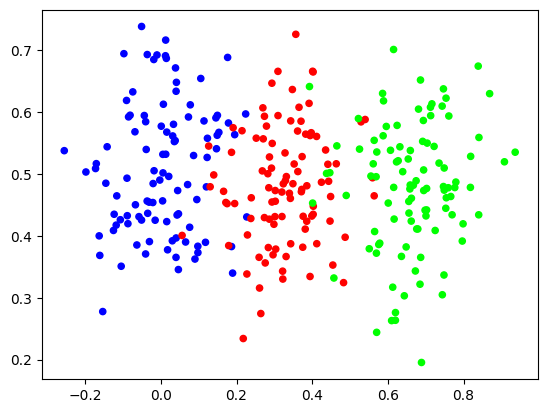

In [6]:
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='brg')
plt.show()

In [7]:
def forward():
  outp0 = activation0.forward(layer0.forward(X))
  outp1 = activation1.forward(layer1.forward(outp0))
  return loss.calculate(y, outp1), accuracy(y, outp1)

In [8]:
forward()

(np.float64(1.1324815222863416), np.float64(0.3333333333333333))

In [9]:
def train(num_epochs: int = 100):
  best_loss, best_accuracy = forward()
  best_0_weights = layer0.weights.copy()
  best_0_biases = layer0.biases.copy()
  best_1_weights = layer1.weights.copy()
  best_1_biases = layer1.biases.copy()

  for epoch in range(num_epochs):
    layer0.weights += 0.0001 * np.random.randn(*layer0.weights.shape)
    layer0.biases += 0.0001 * np.random.randn(*layer0.biases.shape)
    layer1.weights += 0.0001 * np.random.randn(*layer1.weights.shape)
    layer1.biases += 0.0001 * np.random.randn(*layer1.biases.shape)
    new_loss, new_accuracy = forward()
    
    if new_loss < best_loss:
      # print(f"New loss: {new_loss} < {best_loss}")
      best_loss, best_accuracy = new_loss, new_accuracy
      best_0_weights = layer0.weights.copy()
      best_0_biases = layer0.biases.copy()
      best_1_weights = layer1.weights.copy()
      best_1_biases = layer1.biases.copy()
    else:
      layer0.weights = best_0_weights.copy()
      layer0.biases = best_0_biases.copy()
      layer1.weights = best_1_weights.copy()
      layer1.biases = best_1_biases.copy()
    
    # print(new_loss, best_loss, new_loss < best_loss)
  print(best_loss, best_accuracy)


In [39]:
_init_loss, _init_accuracy = forward()
print(_init_loss, _init_accuracy)
train(10000)
_loss, _accuracy = forward()
print(_loss, _accuracy)

0.17277741716180287 0.9333333333333333
0.17277702136599135 0.9333333333333333
0.17277702136599135 0.9333333333333333
